# Линейный классификатор (SVM)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from sklearn.svm import LinearSVC
from sklearn.model_selection import *
from sklearn.metrics import *

## 1. Загрузка данных


In [ ]:
train = load_npz("x_train_tfidf.npz")
test = load_npz("x_test_tfidf.npz")

X_train = train[:, :-1]
y_train = train[:, -1].toarray().ravel()

X_test = test[:, :-1]
y_test = test[:, -1].toarray().ravel()

## 3. Подбор гиперпараметра C



In [ ]:
c_vals = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
m = []
s = []
for c in c_vals:
    model = LinearSVC(C=c, random_state=67)
    scores = cross_val_score(model,X_train,y_train,cv=3,scoring='roc_auc')
    m.append(scores.mean())
    s.append(scores.std())
    print(c, scores.mean())


0.001 0.951117457304719
0.005 0.9720351523004113
0.01 0.9812369798447861
0.05 0.9922621794072319
0.1 0.9942098057981338
0.5 0.9962402747899127
1 0.9964709283985836
5 0.9963825208222383
10 0.9962879699339494


In [ ]:
best_i = np.argmax(m)
best_c = c_vals[best_i]
print("Лучшее C =", best_c)

Лучшее C = 1


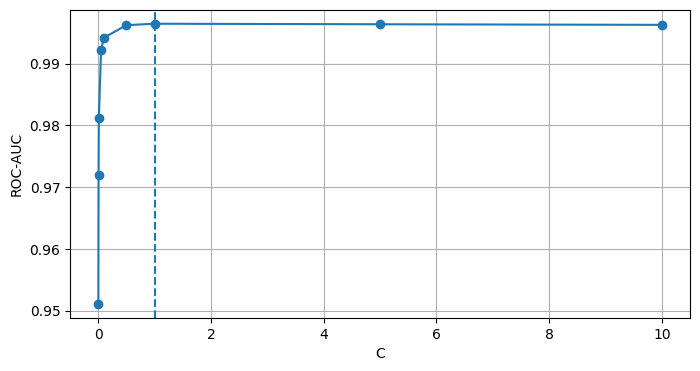

In [ ]:
best_i = np.argmax(m)
best_c = c_vals[best_i]
plt.figure(figsize=(8, 4))
plt.plot(c_vals, m, 'o-')
plt.axvline(best_c, linestyle='--')
plt.xlabel('C')
plt.ylabel('ROC-AUC')
plt.grid()


## 4. Кривая обучения


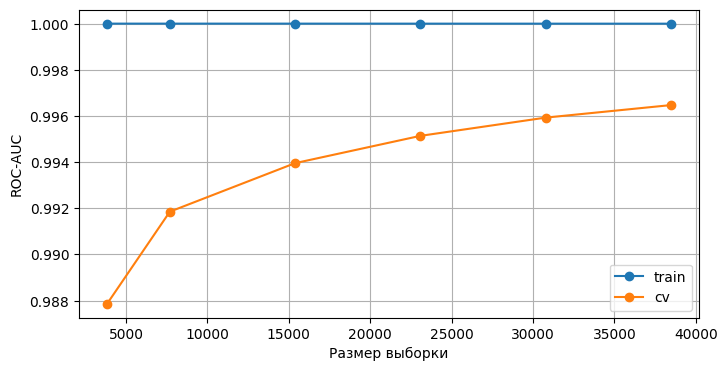

In [ ]:
model = LinearSVC(C=1, random_state=42)
sizes, train_scores, val_scores = learning_curve( model, X_train, y_train, train_sizes=[0.1, 0.2, 0.4, 0.6, 0.8, 1.0], cv=3, scoring='roc_auc')
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
plt.figure(figsize=(8, 4))
plt.plot(sizes, train_mean, 'o-', label='train')
plt.plot(sizes, val_mean, 'o-', label='cv')
plt.xlabel('Размер выборки')
plt.ylabel('ROC-AUC')
plt.legend()
plt.grid()

## 5. Обучение финальной модели


In [ ]:
svc = LinearSVC(C=1, random_state=67)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
y_scores = svc.decision_function(X_test)

## 6. Оценка качества


### 6.1 Классификационный отчёт


In [ ]:
print(classification_report(y_test, y_pred, target_names=['Реальная', 'Фейковая']))

              precision    recall  f1-score   support

    Реальная       0.98      0.97      0.98      7006
    Фейковая       0.98      0.98      0.98      7421

    accuracy                           0.98     14427
   macro avg       0.98      0.98      0.98     14427
weighted avg       0.98      0.98      0.98     14427



In [ ]:
print("Accuracy =", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC =", round(roc_auc_score(y_test, y_pred), 4))
print("F1 =", round(f1_score(y_test, y_pred), 4))

Accuracy = 0.9787
ROC-AUC = 0.9786
F1 = 0.9794


### 6.2 Матрица ошибок


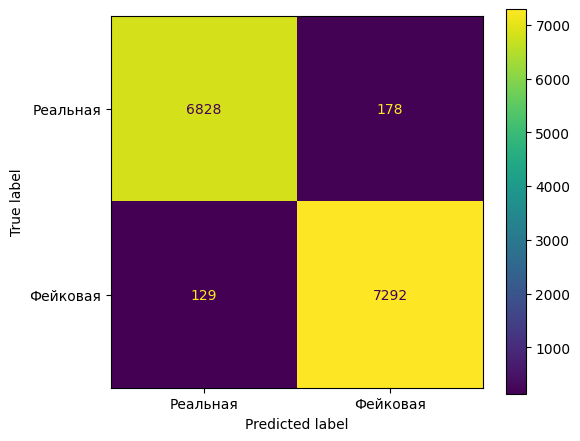

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),display_labels=['Реальная', 'Фейковая']).plot(ax=ax)
plt.show()

### 6.3 ROC и Precision-Recall кривые


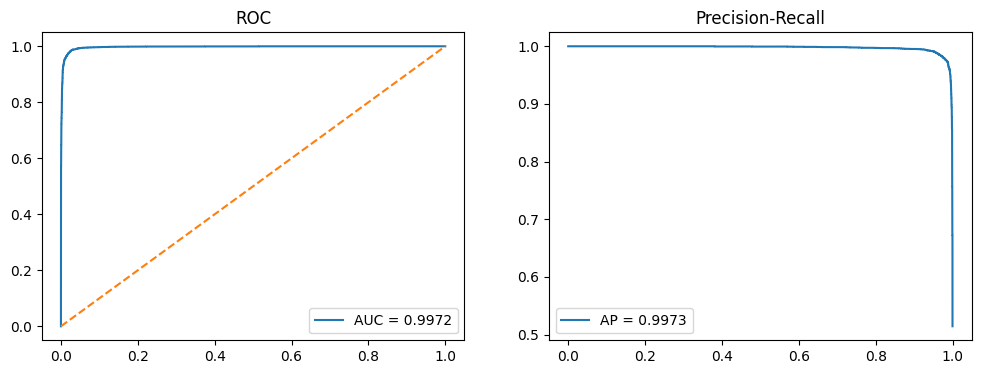

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_scores)
prec, rec, _ = precision_recall_curve(y_test, y_scores)

roc_auc = roc_auc_score(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
ax[0].plot([0, 1], [0, 1], '--')
ax[0].set_title('ROC')
ax[0].legend()

ax[1].plot(rec, prec, label=f'AP = {ap:.4f}')
ax[1].set_title('Precision-Recall')
ax[1].legend()

# Линейная классификация для категорий

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize

In [ ]:
train = load_npz("x_train_cat_tfidf.npz")
test = load_npz("x_test_cat_tfidf.npz")

X_train = train[:, :-1]
y_train = train[:, -1].toarray().ravel()

X_test = test[:, :-1]
y_test = test[:, -1].toarray().ravel()

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

classes = np.unique(y_train)
y_test_bin = label_binarize(y_test,classes=classes)
c_vals = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
m = []
for c in c_vals:
    model = LinearSVC(C=c,random_state=67)
    model.fit(X_train, y_train)
    y_score = model.decision_function(X_test)
    roc_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    m.append(roc_auc)
    print(c, roc_auc)

0.001 0.9381262775848346
0.005 0.9453824410701718
0.01 0.9477824506231778
0.05 0.9489048810476526
0.1 0.9469538127903764
0.5 0.9364867044267445
1 0.929903488124743
5 0.913781219246733
10 0.9081128008370889


In [ ]:
best_i = np.argmax(m)
best_c = c_vals[best_i]
print("Лучшее C =", best_c)

Лучшее C = 0.05


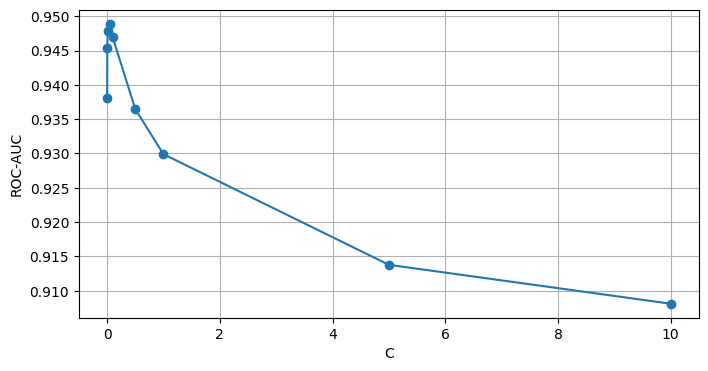

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(c_vals, m, 'o-')
plt.xlabel('C')
plt.ylabel('ROC-AUC')
plt.grid()

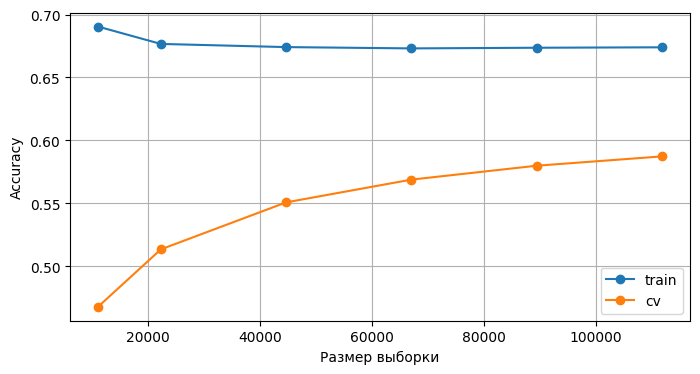

In [ ]:
model = LinearSVC(C= best_c, random_state=67)
sizes, train_scores, val_scores = learning_curve(model, X_train, y_train, train_sizes=[0.1, 0.2, 0.4, 0.6, 0.8, 1.0], cv=3,scoring='accuracy')
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
plt.figure(figsize=(8, 4))
plt.plot(sizes, train_mean, 'o-', label='train')
plt.plot(sizes, val_mean, 'o-', label='cv')
plt.xlabel('Размер выборки')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

In [ ]:
svc = LinearSVC(C=best_c, random_state=67)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.45      0.19      0.26       302
         1.0       0.43      0.07      0.12       268
         2.0       0.57      0.32      0.41       917
         3.0       0.53      0.46      0.49      1198
         4.0       0.51      0.38      0.43       229
         5.0       0.65      0.39      0.49      1080
         6.0       0.53      0.58      0.55       712
         7.0       0.78      0.20      0.32       215
         8.0       0.81      0.67      0.73       685
         9.0       0.53      0.28      0.36       203
        10.0       0.59      0.79      0.68      3473
        11.0       0.64      0.17      0.27       289
        12.0       0.66      0.07      0.12       280
        13.0       0.60      0.79      0.68      1268
        14.0       0.52      0.11      0.19       280
        15.0       0.43      0.32      0.36       524
        16.0       0.50      0.10      0.17      1339
        17.0       0.70    

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

classes = np.unique(y_train)

y_test_bin = label_binarize(y_test, classes=classes)
y_score = svc.decision_function(X_test)
roc_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')

In [ ]:
print("Accuracy =", round(accuracy_score(y_test, y_pred), 4))
print("Macro ROC-AUC =", round(roc_auc, 4))

Accuracy = 0.6049
Macro ROC-AUC = 0.9489


In [ ]:
y_pred = svc.predict(X_test)
y_score = svc.decision_function(X_test)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)
roc_auc_macro = roc_auc_score(y_test_bin,y_score, average='macro', multi_class='ovr')
roc_auc_micro = roc_auc_score(y_test_bin,y_score,average='micro',multi_class='ovr')
pr_auc_macro = average_precision_score( y_test_bin, y_score, average='macro')
pr_auc_micro = average_precision_score( y_test_bin,y_score,average='micro')
print("Macro ROC-AUC =", round(roc_auc_macro, 4))
print("Micro ROC-AUC =", round(roc_auc_micro, 4))
print("Macro PR-AUC =", round(pr_auc_macro, 4))
print("Micro PR-AUC =", round(pr_auc_micro, 4))

Macro ROC-AUC = 0.9489
Micro ROC-AUC = 0.9641
Macro PR-AUC = 0.4707
Micro PR-AUC = 0.6347
